In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler

In [17]:
df = pd.read_csv('Parkison_Dataset.csv')


In [18]:
df

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,250,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,...,3.0706,3.0190,3.1212,2.4921,3.5844,3.5400,3.3805,3.2003,6.8671,0
752,250,0,0.16084,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,...,1.9704,1.7451,1.8277,2.4976,5.2981,4.2616,6.3042,10.9058,28.4170,0
753,251,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,...,51.5607,44.4641,26.1586,6.3076,2.8601,2.5361,3.5377,3.3545,5.0424,0
754,251,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,...,19.1607,12.8312,8.9434,2.2044,1.9496,1.9664,2.6801,2.8332,3.7131,0


In [19]:
#veri kümesinin boyutunu kontrol eder
df.shape

(756, 755)

In [20]:
## Veri setindeki özelliklerin tiplerini ve eksik veri olup olmadığını kontrol edelim
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [21]:
# Veri setinin ilk 5 satırları
print(df.head()) #Bu veri seti, Parkinson hastalığı ile ilgili birçok özellik (PPE, DFA, RPDE vb.) ve son sütunda da sınıf etiketlerini (1 veya 0 olarak) içermektedir. 

   id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0   0       1  0.85247  0.71826  0.57227        240               239   
1   0       1  0.76686  0.69481  0.53966        234               233   
2   0       1  0.85083  0.67604  0.58982        232               231   
3   1       0  0.41121  0.79672  0.59257        178               177   
4   1       0  0.32790  0.79782  0.53028        236               235   

   meanPeriodPulses  stdDevPeriodPulses  locPctJitter  ...  \
0          0.008064            0.000087       0.00218  ...   
1          0.008258            0.000073       0.00195  ...   
2          0.008340            0.000060       0.00176  ...   
3          0.010858            0.000183       0.00419  ...   
4          0.008162            0.002669       0.00535  ...   

   tqwt_kurtosisValue_dec_28  tqwt_kurtosisValue_dec_29  \
0                     1.5620                     2.6445   
1                     1.5589                     3.6107   
2          

In [22]:
# Eksik verileri kontrol edelim
print(df.isnull().sum())

id                           0
gender                       0
PPE                          0
DFA                          0
RPDE                         0
                            ..
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
class                        0
Length: 755, dtype: int64


In [23]:
# Sütun isimlerini kontrol edelim
print(df.columns)

Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_29',
       'tqwt_kurtosisValue_dec_30', 'tqwt_kurtosisValue_dec_31',
       'tqwt_kurtosisValue_dec_32', 'tqwt_kurtosisValue_dec_33',
       'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35',
       'tqwt_kurtosisValue_dec_36', 'class'],
      dtype='object', length=755)


In [24]:
df.isnull().sum() #özniteliklerin değer almadığı kaç satır var?

id                           0
gender                       0
PPE                          0
DFA                          0
RPDE                         0
                            ..
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
class                        0
Length: 755, dtype: int64

In [25]:
df.describe() #Veri kümesinin tanımlayıcı istatistiksel ölçümleri

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,125.500000,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,72.793721,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,62.750000,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,125.500000,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,188.250000,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,251.000000,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


In [26]:
print(df.dtypes)

id                             int64
gender                         int64
PPE                          float64
DFA                          float64
RPDE                         float64
                              ...   
tqwt_kurtosisValue_dec_33    float64
tqwt_kurtosisValue_dec_34    float64
tqwt_kurtosisValue_dec_35    float64
tqwt_kurtosisValue_dec_36    float64
class                          int64
Length: 755, dtype: object


df = df.groupby('id').mean().reset_index()
df.drop('id', axis=1, inplace=True) #sonradaneklendi

columns = list(df.columns) #sonradaneklendi
filtered_columns = [col for col in columns if col != 'class']

# Geçici bir listeyi güncellemek için kullanılan set yapısı
remove_set = set()

for col in filtered_columns:
    for col1 in filtered_columns:
        if col == col1:
            continue

        val = df[col].corr(df[col1])

        if val > 0.7:
            # Yüksek korelasyonlu kolonları işaretleyin
            remove_set.add(col1)

# 'class' kolonunu çıkarmayın
filtered_columns = [col for col in filtered_columns if col not in remove_set]

# Veriyi güncelleyerek yalnızca filtrelenmiş kolonları kullanın
df = df[filtered_columns + ['class']]  # 'class' kolonunu da ekleyin

print("Güncellenmiş Veri Çerçevesi:")
print(df)
print("Yeni şekil:", df.shape)

Yani 755 sütunluk bir özellik uzayını 162 sütunluk bir spesifik alan indirdik. Ancak yine de özellik sayıları örnek veya veri noktası durumunun fazlalığının bu oran çok yüksektir. Bu ifadenin arkasında yatan sebep, özellik alanı genişlemiş veri seti üzerinde genelleme yapmak için gereken örnek süreleri zorlaşması ve modelin performansının düşmesi nedeniyle boyutlu problemin kesintisi ile tutarlı olması.

O halde ki-kare testini kullanarak karakteristik kesiciyi 30'a kadar azaltalım.

Bu kod, SelectKBest sınıfını ve chi2 fonksiyonunu doğru bir şekilde içe aktarır ve en iyi 30 özelliği seçer. get_support() fonksiyonu, hangi özelliklerin seçildiğini belirlemek için kullanılır.

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Özelliklerinizi ve hedef değişkeninizi tanımlayın
X = df.drop('class', axis=1)
y = df['class']

# Veriyi ölçeklendirin
X_norm = MinMaxScaler().fit_transform(X)

# Ki-kare testini kullanarak en iyi 30 özelliği seçin
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, y)

# Seçilen özelliklerin maskesini alın
filtered_columns = selector.get_support()

# Seçilen özelliklerle veri çerçevesini oluşturun
X_selected = X.loc[:, filtered_columns]

print(f"Yeni veri çerçevesinin şekli: {X_selected.shape}")


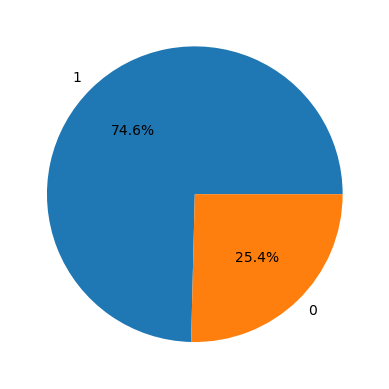

In [27]:
x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()


Veri dengesizliği.

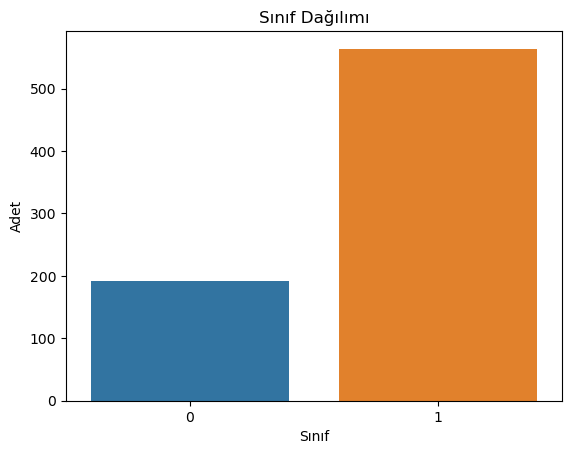

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sınıf dağılımını kontrol et
temp = df["class"].value_counts()
temp_df = pd.DataFrame({'class': temp.index, 'values': temp.values})

# Bar grafiğini oluştur
sns.barplot(x='class', y='values', data=temp_df)
plt.title('Sınıf Dağılımı')
plt.xlabel('Sınıf')
plt.ylabel('Adet')
plt.show()

sns.pairplot(df)

#Aykırı değer varsa göreceğiz grafiğimiz de dağılıma bakıcaz
def boxplots(col):
    sns.boxplots(df[col])
for i in list(df.select_dtypes(exclude =["object"]).columns)[1:]:boxplots(i)

Bağımlı ve bağımsız değişkenleri ayıralım

In [29]:
# Bağımlı ve bağımsız değişkenleri ayırma
x = df.drop(["class", "id"], axis=1)
y = df["class"]

In [30]:
# Etiket dengesizliğini kontrol et
print("Orijinal sınıf dağılımı:", Counter(y))

NameError: name 'Counter' is not defined

features = df.drop('class', axis=1)
target = df['class']

X_train, X_val,\
    Y_train, Y_val = train_test_split(features, target,
                                    test_size=0.2,
                                    random_state=10)
X_train.shape, X_val.shape

# As the data was highly imbalanced we will balance
# it by adding repetitive rows of minority class.
ros = RandomOverSampler(sampling_strategy='minority',
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.shape


In [31]:
import pandas as pd
from collections import Counter

In [32]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import MinMaxScaler


In [33]:
x = df.drop("class", axis=1)  # Özellikler
y = df["class"]  # Etiketler

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [35]:
ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x_scaled, y)


NameError: name 'x_scaled' is not defined

*Oversampling (Aşırı Örnekleme): Azınlık sınıflarından daha fazla örnek oluşturularak veri setinin dengeli hale getirilmesi.
*Bu teknikler, modelin eğitiminde kullanılan veri setinin dengeli olmasını sağlar ve böylece modelin performansı artırılabilir.
*RandomOverSampler kullanarak veri setimizi dengelediğimizde, azınlık sınıflarından daha fazla örnek ekleyerek sınıflar arası dengesizliği düzeltiriz.

x_np = x.values
y_np = y.values

ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x_np, y_np)

print(f"Yeni x_resampled şekli: {x_resampled.shape}")
print(f"Yeni y_resampled şekli: {y_resampled.shape}")


In [36]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x, y)


In [37]:
# Over-sampling ile dengesizliği düzeltme
ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x, y)

In [38]:
# Yeni etiket dağılımını kontrol et
print("Resampled sınıf dağılımı:", Counter(y_resampled))

Resampled sınıf dağılımı: Counter({1: 564, 0: 564})


In [39]:
#verileri ölçeklendirme
#ölçeklendirme önemlidir çünkü PCA maksimum varyans makinesinin yönlerini yakalamayı amaçlar 
#Gradyan iniş tabanlı optimizasyon algoritmaları gibi öğrenme algoritmaları
#(örneğin: Lojistik regresyon), giriş özelliklerinin ölçeğine duyarlıdır I

In [40]:
# Veriyi MinMaxScaler ile ölçeklendirme
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_resampled)

# Ölçeklendirilmiş verinin ilk birkaç satırını kontrol etme
# Ölçeklendirilmiş verilerin istatistiklerini kontrol etme, verilerimizi 0 ve 1 arasında ölçeklendirdik
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
print(x_scaled_df.head())

PCA (Principal Component Analysis) kullanarak veri setinin boyutunu azaltmak için kullanılıyor. PCA, veri setindeki varyansı en iyi şekilde koruyarak daha az sayıda bileşenle veri setini temsil etmeyi sağlar. Bu, özellikle çok sayıda özelliğe (feature) sahip veri setlerinde model performansını artırmak ve işlem süresini azaltmak için yaygın olarak kullanılır.

In [42]:
from sklearn.decomposition import PCA

# %95 varyansı korumak
pca = PCA(n_components=0.95)  # %95 varyansı koruyacak bileşen sayısını belirle
X_PCA = pca.fit_transform(x_scaled)

#Orijinal ve Dönüştürülmüş Veri Setinin Şekillerinin Yazdırılması:
print(x_scaled.shape)
print(X_PCA.shape)


(1128, 754)
(1128, 108)


In [43]:
#PCA Uygulaması ve Veri Setinin Dönüştürülmesi:
#fit_transform metodu, x veri setine PCA uygular ve dönüştürülmüş veri setini X_PCA olarak döndürür
X_PCA = pca.fit_transform(x)

print(f"Ölçeklendirilmiş veri setinin şekli: {x_scaled.shape}")
print(f"PCA sonrası veri setinin şekli: {X_PCA.shape}")
print(f"Açıklanan varyans oranları: {pca.explained_variance_ratio_}")

Orijinal veri setindeki 754 özellik varken, PCA sonrası veri setindeki bu sayı 108e düşmüş. PCA, veri setindeki en önemli özellikleri (başka bir deyişle, en fazla varyansı açıklayan) seçerek boyutları azaltır. Bu, verinizin daha düşük boyutlu bir temsili anlamına gelir.

Neden PCA Kullanılır?
*Boyut İyileştirme: Özellik sayısını azaltarak modelin eğitim süresini ve hesaplama maliyetini azaltır.

*Görselleştirme: Özellikle 2D veya 3D görselleştirmeler için veri boyutunu küçültür.

*Gürültü Azaltma: Düşük varyanslı özellikleri (gürültü olabilecek) çıkartarak modelin performansını iyileştirebilir.

*PCA, veri kümenizdeki en önemli bilgiyi koruyarak özelliği azaltmanıza olanak sağlar. Özellik sayısını azaltırken veri kümenizin yapısını mümkün olduğunca korumaya çalışır.


In [44]:
# Varyans oranlarını ve toplamını hesaplama
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance = explained_variance_ratio.sum()

In [45]:
print("Explained Variance Ratio:", explained_variance_ratio)
print("Total Explained Variance:", total_explained_variance)

Explained Variance Ratio: [0.9999843]
Total Explained Variance: 0.9999843007494843



Varyans oranlarını görselleştirmek için yazdığınız kod neredeyse doğru; ancak, bazı düzeltmeler ve eklemeler yapmamız gerekebilir. explained_variance_ratio değişkenini belirli bir bileşen sayısına göre almanız ve PCA nesnesinin explained_variance_ratio_ özelliğini kullanmanız gerekebilir.

İşte varyans oranlarını görselleştirme kodunuzun tam hali:

Açıklamalar:
Bileşen Sayısı: range(1, len(explained_variance_ratio) + 1) ifadesi, varyans oranlarının her bir bileşen için gösterecek şekilde ayarlanmıştır.

Cumulative Explained Variance: explained_variance_ratio.cumsum() ifadesi, bireysel varyans oranlarının kümülatif toplamını hesaplar ve bunu çizgi grafiği olarak görselleştirir.

Görselleştirme: plt.bar ve plt.step fonksiyonları, bireysel ve kümülatif varyans oranlarını görselleştirmek için kullanılır. plt.tight_layout() grafiğin düzgün görünmesini sağlar.

Bu kod, PCA'nın her bir bileşen için açıklanan varyans oranlarını ve kümülatif varyans oranını net bir şekilde görselleştirir.


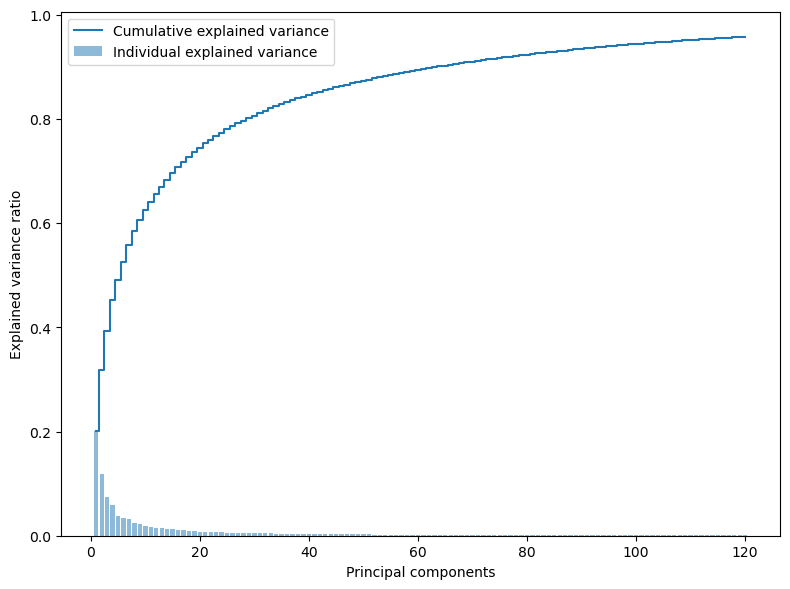

In [46]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA ile bileşenleri belirleme
pca = PCA(n_components=120)
X = pca.fit_transform(x_scaled)

# Açıklanan varyans oranlarını alma
explained_variance_ratio = pca.explained_variance_ratio_

# Varyans oranlarını görselleştirme
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio.cumsum(), where='mid', label='Cumulative explained variance')
plt.xlabel('Principal components')
plt.ylabel('Explained variance ratio')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [53]:
from sklearn.model_selection import train_test_split

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_PCA, y_resampled, test_size=0.2, random_state=7, shuffle=True)


ValueError: Found input variables with inconsistent numbers of samples: [756, 1128]

In [48]:
list_met=[]
list_accuracy=[]

Logistic Regression, Decision Tree, Linear Regression, SVM, KNN ve Gaussian Naive Bayes algoritmalarını kullanarak doğruluk hesaplamalarını yapar ve bir pandas DataFrame'e ekler. Daha sonra, seaborn kullanarak bir bar grafiği oluşturur.

In [49]:
#Algorythms
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import VotingClassifier
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import numpy as np

             Method Used  Accuracy
0    Logistic Regression  0.866667
1          Decision Tree  1.000000
2                    SVM  1.000000
3                    KNN  1.000000
4   Gaussian Naive Bayes  0.977778
5  Bernoulli Naive Bayes  0.800000


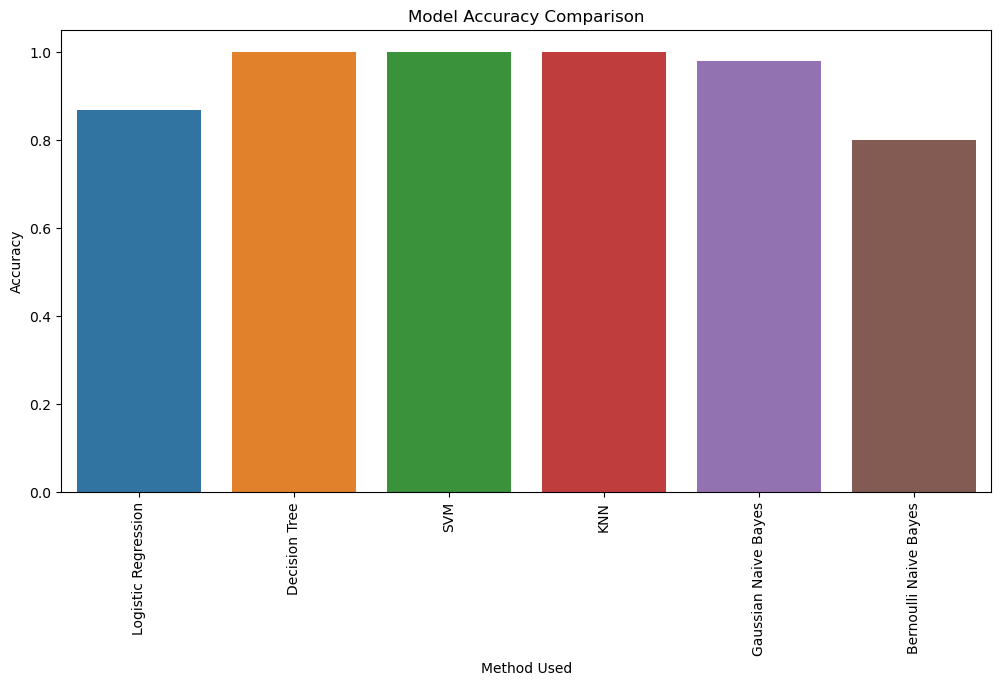

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


# Veri setini eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Veriyi ölçeklendirme (isteğe bağlı)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
lr = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_LR = accuracy_score(y_test, y_pred)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
classifier2 = DecisionTreeClassifier(random_state=14)
dt = classifier2.fit(X_train, y_train)
# Prediction
y_pred2 = classifier2.predict(X_test)
# Accuracy
accuracy_DT = accuracy_score(y_test, y_pred2)

# SVM
from sklearn.svm import SVC
model_svm = SVC(cache_size=100)
svm = model_svm.fit(X_train, y_train)
# Prediction
y_pred3 = model_svm.predict(X_test)
# Accuracy
accuracy_svc = accuracy_score(y_test, y_pred3)

# KNN
from sklearn.neighbors import KNeighborsClassifier
model_knn3 = KNeighborsClassifier(n_neighbors=3)
knn = model_knn3.fit(X_train, y_train)
# Predicting Test Set N-3
pred_knn3 = model_knn3.predict(X_test)
# Accuracy
accuracy_KNN = accuracy_score(y_test, pred_knn3)

# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb = gnb.fit(X_train, y_train)
# Predicting Test Set
pred_gnb = gnb.predict(X_test)
# Accuracy
accuracy_GNB = accuracy_score(y_test, pred_gnb)

# Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb = bnb.fit(X_train, y_train)
# Predicting Test Set
pred_bnb = bnb.predict(X_test)
# Accuracy
accuracy_BNB = accuracy_score(y_test, pred_bnb)

# List of methods and their accuracies
list1 = ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes']
list2 = [accuracy_LR, accuracy_DT, accuracy_svc, accuracy_KNN, accuracy_GNB, accuracy_BNB]
list3 = [classifier, classifier2, model_svm, model_knn3, gnb, bnb]

df_Accuracy = pd.DataFrame({'Method Used': list1, 'Accuracy': list2})
print(df_Accuracy)

# Plotting the results
plt.figure(figsize=(12, 6))
chart = sns.barplot(x="Method Used", y="Accuracy", data=df_Accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
chart.set_title('Model Accuracy Comparison')
chart.set_xlabel('Method Used')
chart.set_ylabel('Accuracy')

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
lr = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_LR = accuracy_score(y_test, y_pred)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
classifier2 = DecisionTreeClassifier(random_state=14)
dt = classifier2.fit(X_train, y_train)
# Prediction
y_pred2 = classifier2.predict(X_test)
# Accuracy
accuracy_DT = accuracy_score(y_test, y_pred2)

# Linear Regression
from sklearn.linear_model import LinearRegression
classifier3 = LinearRegression()
lr_model = classifier3.fit(X_train, y_train)
# Prediction
y_pred3 = classifier3.predict(X_test)
# Accuracy (Round the predictions for classification accuracy)
accuracy_LR_model = accuracy_score(y_test, np.round(y_pred3))

# SVM
from sklearn.svm import SVC
model_svm = SVC(cache_size=100)
svm = model_svm.fit(X_train, y_train)
# Prediction
y_pred5 = model_svm.predict(X_test)
# Accuracy
accuracy_svc = accuracy_score(y_test, y_pred5)

# KNN
from sklearn.neighbors import KNeighborsClassifier
model_knn3 = KNeighborsClassifier(n_neighbors=3)
knn = model_knn3.fit(X_train, y_train)
# Predicting Test Set N-3
pred_knn3 = model_knn3.predict(X_test)
# Accuracy
accuracy_KNN = accuracy_score(y_test, pred_knn3)

# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb = gnb.fit(X_train, y_train)
# Predicting Test Set
pred_gnb = gnb.predict(X_test)
# Accuracy
accuracy_GNB = accuracy_score(y_test, pred_gnb)

# Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb = bnb.fit(X_train, y_train)
# Predicting Test Set
pred_bnb = bnb.predict(X_test)
# Accuracy
accuracy_BNB = accuracy_score(y_test, pred_bnb)

# List of methods and their accuracies
list1 = ['Logistic Regression', 'Decision Tree', 'Linear Regression', 'SVM', 'KNN', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes']
list2 = [accuracy_LR, accuracy_DT, accuracy_LR_model, accuracy_svc, accuracy_KNN, accuracy_GNB, accuracy_BNB]
list3 = [classifier, classifier2, classifier3, model_svm, model_knn3, gnb, bnb]

df_Accuracy = pd.DataFrame({'Method Used': list1, 'Accuracy': list2})
print(df_Accuracy)

# Plotting the results
plt.figure(figsize=(12, 6))
chart = sns.barplot(x="Method Used", y="Accuracy", data=df_Accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
chart.set_title('Model Accuracy Comparison')
chart.set_xlabel('Method Used')
chart.set_ylabel('Accuracy')

plt.show()


 algoritmaları ve ensemble (toplu) sınıflandırıcıyı değerlendirecek

# Eğitim ve test setlerine bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Classifierlar
clf1 = DecisionTreeClassifier()
clf2 = KNeighborsClassifier()
clf3 = SVC(kernel='linear')
clf4 = LogisticRegression(max_iter=1000)
clf5 = GaussianNB()
clf6 = BernoulliNB()

# Ensemble Classifier
eclf = VotingClassifier(estimators=[
    ('dt', clf1), 
    ('knn', clf2), 
    ('svc', clf3)
], voting='hard')

# Her sınıflandırıcı için çapraz doğrulama
for clf, label in zip([clf1, clf2, clf3, clf4, clf5, clf6, eclf], 
                      ['DecisionTree', 'KNN', 'SVM', 'LogisticRegression', 'GaussianNB', 'BernoulliNB', 'Ensemble']):
    scores = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=5)
    print("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

In [51]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [52]:
#XBoost
#This classifies using extreme Gradient Boosting- using gradient boosting algorithms for modern data science problems.
#It falls alls under the category of Ensemble Learning in ML
#makes our data output more superior

from xgboost import XGBClassifier
model_xg=XGBClassifier()
model_xg.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [54]:
# Initialize the model
model_xg = XGBClassifier()

# Fit the model
model_xg.fit(X_train, y_train)

# Make predictions
y_pred = model_xg.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [55]:
#confusion matrix
#when diagnosing a health
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, model_xg.predict(X_test))

In [56]:
#f1-score
from sklearn.metrics import f1_score
#f1_score(y_test, model_xg.predict(X_test), average='binary")
  # Modelinizin tahminlerini yapın
y_pred = model_xg.predict(X_test)

# F1 puanını hesaplayın
f1 = f1_score(y_test, y_pred, average='binary')

print("F1 Score:", f1)       

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [57]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
print(classification_report(y_test, model_xg.predict(X_test)))
print('Confusion Matrix:')
print(cm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [58]:
for i in list3:
    print("********************* ",i,"********************* ")
    print(classification_report(y_test, i.predict(X_test)))

    print('Confusion Matrix:')
    print(cm)
    print()

*********************  LogisticRegression(C=0.4, max_iter=1000, solver='liblinear') ********************* 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.54      0.70        13
           2       0.68      1.00      0.81        13

    accuracy                           0.87        45
   macro avg       0.89      0.85      0.84        45
weighted avg       0.91      0.87      0.86        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

*********************  DecisionTreeClassifier(random_state=14) ********************* 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00 

In [ ]:
XBoosts.3png de kaldım..